In [1]:
import h5py
import psana
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import  rotate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit,minimize
import multiprocessing
import os
from functools import partial
import time
import sys
import argparse
from datetime import datetime
import tempfile
import XSpect.XSpect_Analysis
import XSpect.XSpect_Controller
import XSpect.XSpect_Visualization
import XSpect.XSpect_PostProcessing
import XSpect.XSpect_Diagnostics

In [2]:
start=time.time()
xas_experiment = XSpect.XSpect_Analysis.spectroscopy_experiment(lcls_run=21, hutch='xcs', experiment_id='xcsl1004021')
xas=XSpect.XSpect_Controller.XASBatchAnalysis()
keys=['epics/ccm_E','epics/ccm_E_setpoint','tt/ttCorr','epics/lxt_ttc', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL','epix_1/ROI_0_sum'] 
names=['ccm','ccm_E_setpoint','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl','epix']
xas.set_key_aliases(keys,names)
xas.add_filter('xray','ipm',100.0)
xas.add_filter('simultaneous','ipm',100.0)
xas.add_filter('simultaneous','time_tool_ampl',0.01)
xas.run_parser(['298-304 307-311']) # 7.5 uJ -0.5 to 2 ps
xas.mintime = -2
xas.maxtime = 10
xas.numpoints = 240
xas.scattering=False
# xas.primary_analysis_parallel_loop(4,xas_experiment)
xas.primary_analysis_loop(xas_experiment)
end=time.time()
print('Time binning: {} ps steps'.format(np.min(np.diff(xas.time_bins))))

/sdf/home/l/lbgee/UW_2025_Talk/XSpect/XSpect/XSpect_Controller.py:124: UserWarning: If you plan on using delayed key loading for the epix then please define key_epix and friendly_name_epix. And do not load it here for risk of OOM
  warnings.warn('If you plan on using delayed key loading for the epix then please define key_epix and friendly_name_epix. And do not load it here for risk of OOM')


Time binning: 0.05020920502091997 ps steps


Text(0.5, 1.0, 'xcsl1004021 298-304 307-311')

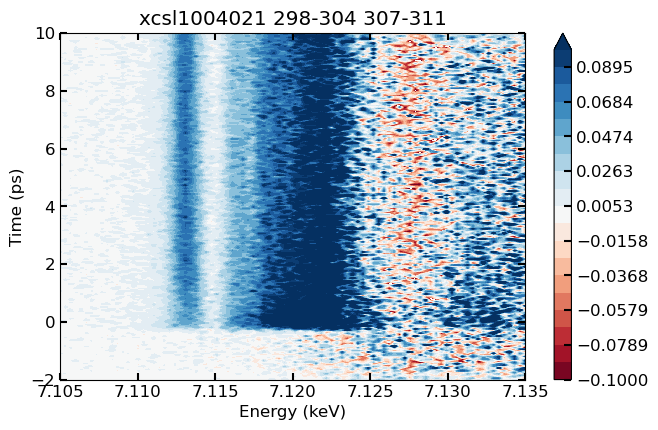

In [3]:
v=XSpect.XSpect_Visualization.XASVisualization()
v.combine_spectra(xas_analysis=xas,
                  xas_laser_key='epix_simultaneous_laser_time_energy_binned',
                  xas_key='epix_xray_not_laser_time_energy_binned',
                  norm_laser_key='ipm_simultaneous_laser_time_energy_binned',
                  norm_key='ipm_xray_not_laser_time_energy_binned',
                 interpolate=False)
v.vmin=-0.2
v.vmax=0.2
v.plot_2d_difference_spectrum(xas,vmin=v.vmin,vmax=v.vmax)
plt.title('xcsl1004021 298-304 307-311')


In [4]:
np.shape(xas.summed_norm_on)

(240, 90)

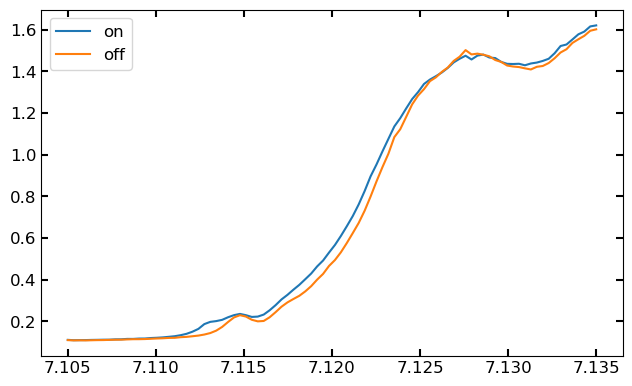

In [5]:
plt.plot(xas.ccm_bins,np.nansum(xas.summed_laser_on,axis=0)/np.nansum(xas.summed_norm_on,axis=0))
plt.plot(xas.ccm_bins,np.nansum(xas.summed_laser_off,axis=0)/np.nansum(xas.summed_norm_off,axis=0))
plt.legend(['on','off'])

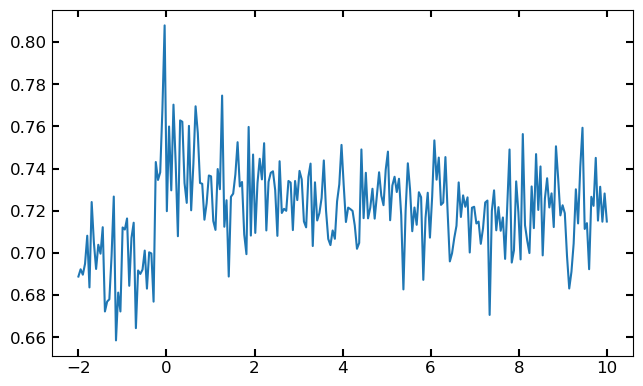

In [8]:
plt.plot(xas.time_bins,np.nansum(xas.summed_laser_on,axis=1)/np.nansum(xas.summed_norm_on,axis=1))